In [10]:
import os
import pandas as pd
import numpy as np
import csv
import sys
sys.path.append('../../python/')
import Simulating_detector_version_5 as sim_data
import pq_dist_v6 as pq1
import adaptive_bining_1 as binning

In [11]:
seed_value = 8
Er_frac =0
s0 =0
F0= 0.122
ptqi= sim_data.generate_statistical_simulated_data(sim_data.generate_Er_G(seed_value),sim_data.generate_Er_N(seed_value), Er_frac, F0, s0, seed_value)
pt = np.asarray(ptqi["EP"])
qi = np.asarray(ptqi["EQ"])
len(pt), len(qi),pt.min(), pt.max(), qi.min(), qi.max()

(94645,
 94645,
 0.00041834495908055214,
 325.60453554014316,
 0.00010044789447793967,
 97.19350547700658)

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import scipy.integrate
from scipy.stats import multivariate_normal

def multivariate_probability_binning_xy(x, y, n_bins=128, plot=True):
    """
    Perform multivariate probability binning on 2D data given as x and y arrays.

    Parameters:
    -----------
    x : np.ndarray
        1D array of x-coordinates of data points
    y : np.ndarray
        1D array of y-coordinates of data points
    n_bins : int
        Number of bins to create (2^N)
    plot : bool
        If True, plot data with bin rectangles

    Returns:
    --------
    counts : np.ndarray
        Array of counts per bin
    bin_info : list of tuples
        List of bins as (xmin, xmax, ymin, ymax)
    """

    data = np.column_stack((x, y))  # Combine into 2D array

    def recursive_bin(data, n_bins, bounds=None):
        dims = data.shape[1]

        if bounds is None:
            bounds = [(data[:, i].min(), data[:, i].max()) for i in range(dims)]

        # Base case
        if n_bins == 1 or len(data) == 0:
            return [(bounds, np.arange(data.shape[0]))]

        # Find dimension with largest variance
        var = np.var(data, axis=0)
        split_dim = np.argmax(var)

        # Split at median
        median = np.median(data[:, split_dim])
        left_idx = np.where(data[:, split_dim] <= median)[0]
        right_idx = np.where(data[:, split_dim] > median)[0]

        # Update bounds
        left_bounds = bounds.copy()
        right_bounds = bounds.copy()
        left_bounds[split_dim] = (bounds[split_dim][0], median)
        right_bounds[split_dim] = (median, bounds[split_dim][1])

        # Recursive splitting
        bins_left = recursive_bin(data[left_idx], n_bins // 2, left_bounds)
        bins_right = recursive_bin(data[right_idx], n_bins - n_bins // 2, right_bounds)

        return bins_left + bins_right

    # ================== Create bins ==================
    bins = recursive_bin(data, n_bins)

    # ================== Extract counts and bin info ==================
    counts = np.array([len(b[1]) for b in bins])
    bin_info = [tuple([float(b[0][0][0]), float(b[0][0][1]), 
                       float(b[0][1][0]), float(b[0][1][1])]) 
                for b in bins]

    # ================== Plot ==================
    if plot:
        plt.figure(figsize=(8, 8))
        plt.scatter(x, y, s=5, alpha=0.5)
        plt.xlim(x.min(), x.max())
        plt.ylim(y.min(), y.max())
        for r in bin_info:
            rect = Rectangle((r[0], r[2]), r[1]-r[0], r[3]-r[2], 
                             edgecolor='red', facecolor='none', lw=1)
            plt.gca().add_patch(rect)
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.title(f"Multivariate Probability Binning ({len(x)} points, {n_bins} bins)")
        plt.show()

    return counts, bin_info

def multivariate_probability_binning_xy(x, y, n_bins=128, plot=True, 
                                        xmin=None, xmax=None, ymin=None, ymax=None):
    """
    Perform multivariate probability binning on 2D data given as x and y arrays,
    with optional limits to restrict the binning region.

    Parameters:
    -----------
    x : np.ndarray
        1D array of x-coordinates of data points
    y : np.ndarray
        1D array of y-coordinates of data points
    n_bins : int
        Number of bins to create (2^N)
    plot : bool
        If True, plot data with bin rectangles
    xmin, xmax, ymin, ymax : float, optional
        Limits for x and y coordinates. Points outside are ignored.

    Returns:
    --------
    counts : np.ndarray
        Array of counts per bin
    bin_info : list of tuples
        List of bins as (xmin, xmax, ymin, ymax)
    """
    
    # Apply filter if limits are given
    mask = np.ones_like(x, dtype=bool)
    if xmin is not None:
        mask &= (x >= xmin)
    if xmax is not None:
        mask &= (x <= xmax)
    if ymin is not None:
        mask &= (y >= ymin)
    if ymax is not None:
        mask &= (y <= ymax)
    
    x_filtered = x[mask]
    y_filtered = y[mask]
    data = np.column_stack((x_filtered, y_filtered))

    def recursive_bin(data, n_bins, bounds=None):
        dims = data.shape[1]

        if bounds is None:
            bounds = [(data[:, i].min(), data[:, i].max()) for i in range(dims)]

        if n_bins == 1 or len(data) == 0:
            return [(bounds, np.arange(data.shape[0]))]

        var = np.var(data, axis=0)
        split_dim = np.argmax(var)

        median = np.median(data[:, split_dim])
        left_idx = np.where(data[:, split_dim] <= median)[0]
        right_idx = np.where(data[:, split_dim] > median)[0]

        left_bounds = bounds.copy()
        right_bounds = bounds.copy()
        left_bounds[split_dim] = (bounds[split_dim][0], median)
        right_bounds[split_dim] = (median, bounds[split_dim][1])

        bins_left = recursive_bin(data[left_idx], n_bins // 2, left_bounds)
        bins_right = recursive_bin(data[right_idx], n_bins - n_bins // 2, right_bounds)

        return bins_left + bins_right

    # Create bins
    bins = recursive_bin(data, n_bins)

    # Extract counts and bin info
    counts = np.array([len(b[1]) for b in bins])
    bin_info = [tuple([float(b[0][0][0]), float(b[0][0][1]), 
                       float(b[0][1][0]), float(b[0][1][1])]) 
                for b in bins]

    # Plot
    if plot:
        plt.figure(figsize=(8, 8))
        plt.scatter(x_filtered, y_filtered, s=5, alpha=0.5)
        
        for r in bin_info:
            rect = Rectangle((r[0], r[2]), r[1]-r[0], r[3]-r[2], 
                             edgecolor='red', facecolor='none', lw=1)
            plt.gca().add_patch(rect)
        plt.xlabel("X")
        plt.ylabel("Y")
        # plt.xlim(x_filtered.min(), x_filtered.max())
        # plt.ylim(y_filtered.min(), y_filtered.max())
        plt.xlim(2.5, 20)
        plt.ylim(0.25, 10)
        plt.title(f"Multivariate Probability Binning ({len(x_filtered)} points, {n_bins} bins)")
        plt.savefig("paper_biinnin_for_our_data", dpi=300, bbox_inches='tight')
        plt.show()

    return counts, bin_info

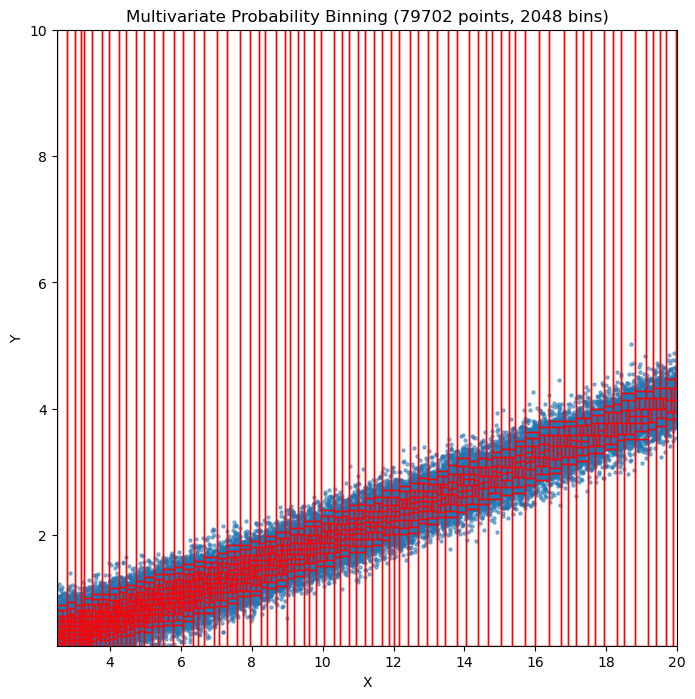

[39 39 39 ... 39 39 38]


In [13]:
x = pt
y = qi
xmin = 2.5
xmax = 350 
ymin = 0.25
ymax = 200
n_bins = 2048
counts, bins_info = multivariate_probability_binning_xy(x, y, n_bins=n_bins, plot=True,xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax)
print(counts)

In [14]:
import numpy as np

with open("S_0_observedCounts_equal_prob_NR.txt", "w") as f:
    # Convert to list and write as string
    f.write(str(counts.tolist()))

In [15]:
import pprint
with open("S_0_bin_info_equal_prob_Cf.txt", "w") as f:
    pprint.pprint(bins_info, stream=f, width=120)

In [16]:
import pprint

# with open("bin_info_equal_prob.txt", "w") as f:
#     pprint.pprint(bins_info, stream=f, width=120)

def flatten_bins_list_to_txt(bins_info, output_file):
    with open(output_file, "w") as f:
        for i, (xlo, xhi, ylo, yhi) in enumerate(bins_info):
            f.write(f"{xlo} {xhi} {ylo} {yhi} 0_{i}\n")
    print(f"Flattened bins saved to {output_file}")

flatten_bins_list_to_txt(bins_info, "S_0_job_args_er_2000.txt")

Flattened bins saved to S_0_job_args_er_2000.txt
